In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# 데이터 불러오기

In [2]:
housing = pd.read_csv('https://raw.githubusercontent.com/devdio/flyai_datasets/refs/heads/main/housing.csv')

In [3]:
housing.shape

(20640, 10)

In [4]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Target : median_house_value (집값)

In [5]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


# EDA

In [6]:
housing.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [7]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


total_bedrooms 에만 결측치 존재

평균으로 채우자.

train에서 평균 구하고, 똑같은 값을 나중에 test에도 써야해.

In [8]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# Train, Test 나누기

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x = housing.drop('median_house_value', axis=1)
y = housing['median_house_value']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=SEED, shuffle=True)

# 데이터 전처리

## 결측치 해결

In [16]:
m = x_train['total_bedrooms'].mean()
x_train['total_bedrooms'] = x_train['total_bedrooms'].fillna(m)

## Encoding

x의 ocean proximity 가 필요


In [17]:
from sklearn.preprocessing import OneHotEncoder

In [18]:
x_categorical_cols = ['ocean_proximity']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
x_ohe = pd.DataFrame(
                    data = ohe.fit_transform(x_train[x_categorical_cols]),
                    columns = ohe.get_feature_names_out(x_categorical_cols),
                    index = x_train.index
                    )

x_train_e = pd.concat([x_train.drop(x_categorical_cols, axis=1), x_ohe], axis=1)

## Scaling

Linear Regression 에서는 보통 Scaling 안함.

x만 하면 됨

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
x_scaler = StandardScaler()
x_scaler.fit(x_train_e)
x_train_e_s = x_scaler.transform(x_train_e)

y는 log 변환

In [22]:
y_train = np.log1p(y_train)

# 모델 학습

In [23]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train_e_s, y_train)

lr.coef_, lr.intercept_

(array([-0.32841775, -0.3402974 ,  0.03332621, -0.02913758,  0.16016532,
        -0.19910164,  0.1020216 ,  0.32333538,  0.05458834, -0.09012847,
         0.01013622,  0.0211751 ,  0.02393785]),
 np.float64(12.086500661969968))

# 테스트

## 데이터 전처리

### Encoding

In [24]:
x_test['total_bedrooms'] = x_test['total_bedrooms'].fillna(m)

In [25]:
x_ohe_test = pd.DataFrame(
                    data = ohe.transform(x_test[x_categorical_cols]),
                    columns = ohe.get_feature_names_out(x_categorical_cols),
                    index = x_test.index
                    )

x_test_e = pd.concat([x_test.drop(x_categorical_cols, axis=1), x_ohe_test], axis=1)

### Scaling

In [26]:
x_test_e_s = x_scaler.transform(x_test_e)

## 테스트 시행

In [27]:
y_predict = lr.predict(x_test_e_s)

## 결과 확인

로그 역변환

In [28]:
y_predict = np.expm1(y_predict)

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def print_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    print(f"1. Mean Squared Error (MSE): {mse:.4f}")

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"2. Root Mean Squared Error (RMSE): {rmse:.4f}")

    # MAE 계산
    mae = mean_absolute_error(y_true, y_pred)
    print(f"3. Mean Absolute Error (MAE): {mae:.4f}")

    # R^2 Score 계산
    r2 = r2_score(y_true, y_pred)
    print(f"4. R-squared (R^2) Score: {r2:.4f}")

print_metrics(y_test, y_predict)

1. Mean Squared Error (MSE): 7948382003.9133
2. Root Mean Squared Error (RMSE): 89153.6988
3. Mean Absolute Error (MAE): 52264.7076
4. R-squared (R^2) Score: 0.3934


그래프 그리기

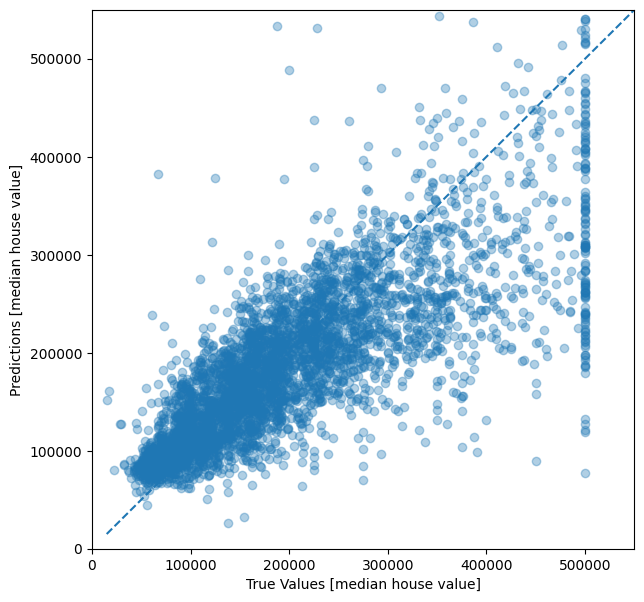

In [31]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_predict, alpha=0.35)
plt.xlabel('True Values [median house value]')
plt.ylabel('Predictions [median house value]')
min_val = min(y_test.min(), y_predict.min())
max_val = max(y_test.max(), y_predict.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.xlim(0, 550000)
plt.ylim(0, 550000)
plt.show()

# 문제 분석

1. California housing target은 500001에서 capped 되어 있음

2. log 변환 후 expm1로 되돌리면서 일부 예측이 크게 튐

3. Linear Regression은 극단값에 약함